### T3 Download the data set cancer_data.csv from Canvas. 
- The dataset contains a set of 3047 records under 33 features with target variable Target_deathRate.

 - Using linear regression (simple or multiple), develop a model to predict cancer death rates. 
 - What can you conclude about your model? 
 - How strong is the linear relation-ship between the predictor and target variables?

In [47]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # MATLAB-like way of plotting
from mpl_toolkits.mplot3d import Axes3D
# sklearn package for machine learning in python:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

In [25]:
df = pd.read_csv('cancer_data.csv') # read data (make sure .csv in folder)

In [26]:
#print(df.head(),'\n') # print first 5 rows of data


In [27]:
#print(df.info(),'\n') # print first 5 rows of data


In [28]:
# Step 2: Sanitize the data
# Strip whitespace from column names (just in case)
df.columns = df.columns.str.strip().str.replace(" ", "")

In [29]:
# Optionally drop rows with missing values
df.dropna(inplace=True)

In [37]:
# Drop non-numeric columns before modeling
df_cleaned = df.drop(columns=["binnedInc", "Geography"], errors='ignore')  # 'ignore' skips if not found

In [35]:
# Step 3: Separate features and target variable
# X contains the predictor (independent) variables
# y contains the target variable we want to predict (cancer death rate)
X = df_cleaned.drop(columns="TARGET_deathRate")  # All columns except the target
y = df_cleaned["TARGET_deathRate"]              # The target variable


In [36]:
# Step 5: Scale the features using Min-Max Scaling (0 to 1)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)  # Returns a numpy array with scaled values


In [40]:
# Step 6: Split the data into training and testing sets (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

In [41]:
# Step 5: Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [42]:
# Step 6: Make predictions on the test data
y_pred = model.predict(X_test)

In [44]:
# Step 7: Evaluate the model
r2 = r2_score(y_test, y_pred)                     # R-squared score
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Root Mean Squared Error

In [45]:
# Step 8: Print results
print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)
print("R² Score (explained variance):", round(r2, 4))
print("RMSE (error magnitude):", round(rmse, 4))


Model Coefficients: [ -184.58313073   153.97231645   112.50496636    17.18379386
    32.22679602   -20.21746519     2.2975304     -7.70651949
   -40.30929215    25.22012374    -2.24540146   100.63187622
 -1272.64122385 -1710.97735846 -1881.11349982  -770.17244592
    27.97470527   -27.58265026   -63.21746619    22.86484536
    22.68885406   -49.71945057    36.33065138   -90.37723341
    96.79436077    21.23113704    21.68446141     8.13903666
   -34.57155484  -134.57585533   -11.62578395]
Model Intercept: 2411.1449206096704
R² Score (explained variance): 0.2824
RMSE (error magnitude): 21.4496


In [51]:
print("Multiple Regression R²:", round(r2, 4))
print("RMSE:", round(rmse, 4))

Multiple Regression R²: 0.2824
RMSE: 21.4496


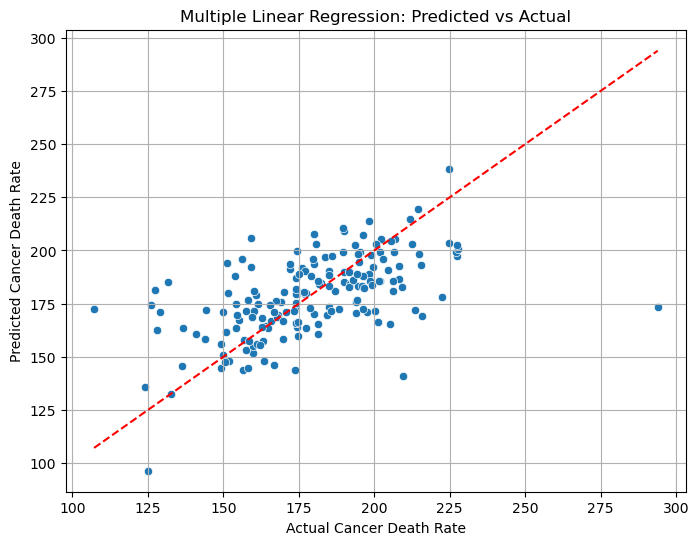

In [48]:
# 🔹 Plot: Predicted vs Actual
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual Cancer Death Rate")
plt.ylabel("Predicted Cancer Death Rate")
plt.title("Multiple Linear Regression: Predicted vs Actual")
plt.grid(True)
plt.show()

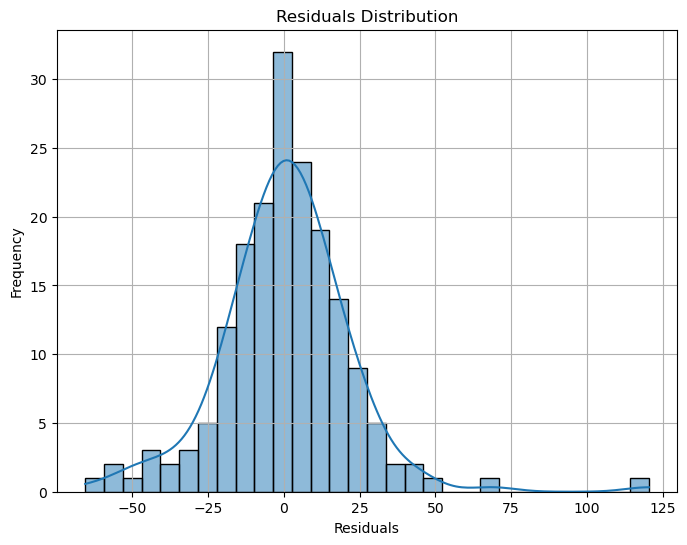

In [50]:
# 🔹 Plot: Residuals
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

### Simple Linear Regression with Visualization

In [59]:
# Use a copy to avoid messing with the original DataFrame
df_simple = df.copy()

In [60]:
# Drop rows with missing values
df_simple.dropna(subset=["povertyPercent", "TARGET_deathRate"], inplace=True)

In [61]:
# Feature and target
X = df_simple[["povertyPercent"]]  # Predictor must be 2D
y = df_simple["TARGET_deathRate"]

In [62]:
# Scale the features using Min-Max Scaling (0 to 1)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)  # Returns a numpy array with scaled values


In [65]:

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [66]:
# Step 7: Evaluate the model
r2 = r2_score(y_test, y_pred)                     # R-squared score
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Root Mean Squared Error

In [67]:
# Step 8: Print results
print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)
print("R² Score (explained variance):", round(r2, 4))
print("RMSE (error magnitude):", round(rmse, 4))

Model Coefficients: [1.74622783]
Model Intercept: 150.31343088008606
R² Score (explained variance): 0.0065
RMSE (error magnitude): 26.5426


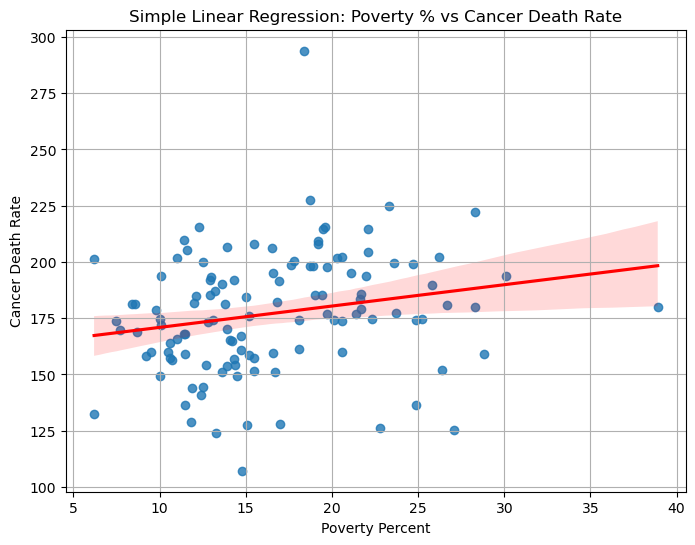

In [68]:
# Predict
y_pred = model.predict(X_test)

# 🔹 Plot: Regression Line
plt.figure(figsize=(8,6))
sns.regplot(x=X_test["povertyPercent"], y=y_test, line_kws={"color": "red"})
plt.xlabel("Poverty Percent")
plt.ylabel("Cancer Death Rate")
plt.title("Simple Linear Regression: Poverty % vs Cancer Death Rate")
plt.grid(True)
plt.show()

In [69]:
# Use a copy to avoid messing with the original DataFrame
df_m = df.copy()

In [76]:
# Drop rows with missing values
df_m.dropna(subset=["povertyPercent", "TARGET_deathRate","PctUnemployed16_Over"], inplace=True)

In [81]:
X_3d = df_m[["povertyPercent", "PctUnemployed16_Over"]].dropna()
y = df_m["TARGET_deathRate"]

In [92]:
# Convert to NumPy arrays
X_3d_np = X_3d.to_numpy()
y_3d_np = y_3d.to_numpy()

In [93]:
# Scale the features using Min-Max Scaling (0 to 1)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_3d_np)  # Returns a numpy array with scaled values

In [95]:

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [97]:
# Step 7: Evaluate the model
r2 = r2_score(y_test, y_pred)                     # R-squared score
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Root Mean Squared Error

In [106]:
# Step 8: Print results
print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)
print("R² Score (explained variance):", round(r2, 4))
print("RMSE (error magnitude):", round(rmse, 4))
print('Mean squared error: %.8f'
% mean_squared_error(y_test, model.predict(X_test)))

Model Coefficients: [-0.00905616  0.02079773]
Model Intercept: 181.6988999485914
R² Score (explained variance): 0.0065
RMSE (error magnitude): 26.5426
Mean squared error: 744.81714646


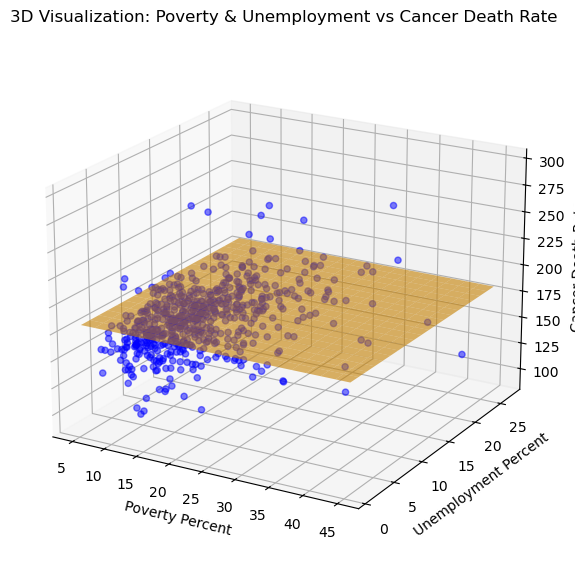

In [112]:

# 3D Scatter Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

#Create grid to plot the plane
x_range = np.linspace(X_3d.iloc[:, 0].min(), X_3d.iloc[:, 0].max(), 20)
y_range = np.linspace(X_3d.iloc[:, 1].min(), X_3d.iloc[:, 1].max(), 20)

xx, yy = np.meshgrid(x_range, y_range)
zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)


# Scatter plot
#ax.scatter(X_3d_np[:, 0], X_3d_np[:, 1], y_3d_np, color='blue', alpha=0.6)
ax.scatter(X_3d.iloc[:, 0], X_3d.iloc[:, 1], y_3d, color='blue', alpha=0.5, label="Actual Data")

# Regression plane
ax.plot_surface(xx, yy, zz, color='orange', alpha=0.6, label="Regression Plane")


# Set viewpoint and labels
#ax.azim = -60  # Left-right rotation
#ax.elev = 20   # Up-down elevation
#ax.dist = 10

ax.view_init(elev=20, azim=-60)

ax.set_title('3D Visualization: Poverty & Unemployment vs Cancer Death Rate')
ax.set_xlabel('Poverty Percent')
ax.set_ylabel('Unemployment Percent')
ax.set_zlabel('Cancer Death Rate')
plt.show()

### What can you conclude about your model?:

 - The strength of the linear relationship between the predictor variables and cancer death rates is:

 - Very weak when using single or two predictors (e.g., poverty, unemployment), they explain almost none of the variation in cancer death rates.

 - Moderate when using all available features in a multiple regression model,  the model explains about 28% of the variance, indicating some predictive power but also suggesting the relationship is not strongly linear and likely influenced by other (possibly nonlinear or external) factors.

### find the top 5 features (fields) with the strongest impact on predicting TARGET_deathRate

In [123]:
# STEP 1: Drop non-numeric or problematic columns
df_cleaned = df.drop(columns=['TARGET_deathRate','binnedInc', 'Geography'])

# STEP 2: Store feature names
feature_names = df_cleaned.columns

In [124]:

# STEP 3: Scale the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_cleaned)

# STEP 4: Target variable
y = df["TARGET_deathRate"]


In [125]:
# STEP 5: Fit linear regression
model = LinearRegression()
model.fit(X_scaled, y)


LinearRegression()

In [126]:

# STEP 6: Get coefficients and pair them with feature names
coefs = model.coef_
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs,
    'Abs_Coefficient': np.abs(coefs)  # Use absolute value to find strongest influence
})

In [127]:
# STEP 7: Sort and get top 5
top_5_features = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(5)
print(top_5_features[['Feature', 'Coefficient']])

            Feature  Coefficient
14  PctSomeCol18_24 -1616.670146
13       PctHS18_24 -1465.813657
12     PctNoHS18_24 -1102.092422
15  PctBachDeg18_24  -663.028835
2     incidenceRate   126.497537


In [129]:
top_5_names = top_5_features["Feature"].tolist()

In [135]:
# Use only top 5 features
X_top5 = df[top_5_names]
X_top5_scaled = scaler.fit_transform(X_top5)

In [136]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_top5_scaled, y, test_size=0.2, random_state=42)

# Train model
model_top5 = LinearRegression()
model_top5.fit(X_train, y_train)

LinearRegression()

In [140]:
# Predict
y_pred = model_top5.predict(X_test)

In [141]:
# Step 7: Evaluate the model
r2 = r2_score(y_test, y_pred)                     # R-squared score
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Root Mean Squared Error

In [142]:
# Step 8: Print results
print("Model Coefficients:", model_top5.coef_)
print("Model Intercept:", model_top5.intercept_)
print("R² Score (explained variance):", round(r2, 4))
print("RMSE (error magnitude):", round(rmse, 4))
print('Mean squared error: %.8f'
% mean_squared_error(y_test, model_top5.predict(X_test)))

Model Coefficients: [-2891.55703547 -2602.07408379 -1937.20762307 -1196.07917003
   154.23604858]
Model Intercept: 3561.4088956914984
R² Score (explained variance): 0.2315
RMSE (error magnitude): 23.3449
Mean squared error: 544.98276829


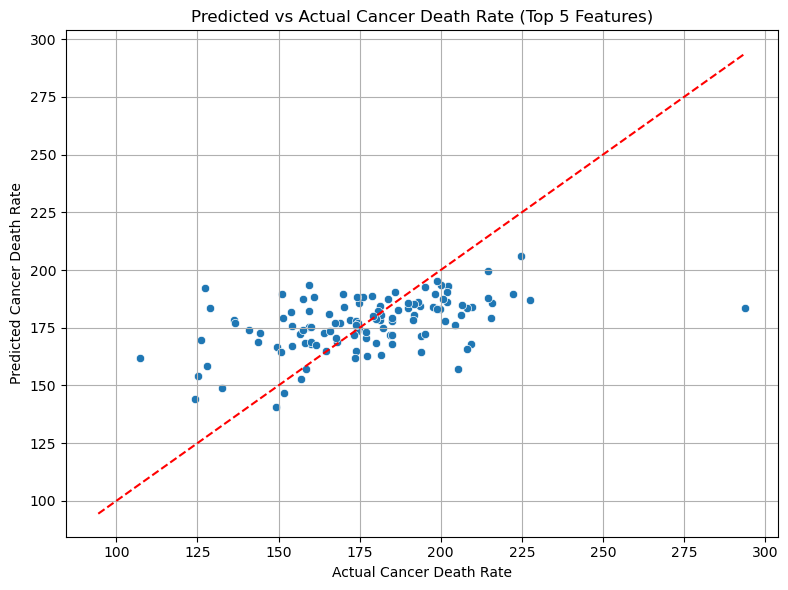

In [139]:
# Visualization: Predicted vs Actual
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)

plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Cancer Death Rate")
plt.ylabel("Predicted Cancer Death Rate")
plt.title("Predicted vs Actual Cancer Death Rate (Top 5 Features)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Print top 5 features and their coefficients
#print(top_5_features[["Feature", "Coefficient"]])

# Conclusion

- How strong is the linear relationship?
      - The top 5 features model shows a moderate linear relationship. It explains 23.15% of the variance, which is a substantial improvement over the single and 2-feature models but not as good as using all features.
      - An R² of ~0.23 is not very high but shows that these features capture some key drivers of cancer death rates.

- Compared to other models:
  - Using just 1 or 2 features (like poverty or unemployment) is insufficient for meaningful predictions.
  - The top 5 features approach offers a good trade-off between simplicity and predictive power.
  - The full model still performs the best overall in terms of both R² and RMSE, indicating that more predictors contribute to accuracy, despite potential noise.

- 
- Model Improvement Suggestions:
     - Try regularization techniques (like Ridge or Lasso) to handle multicollinearity.
     - Explore non-linear models (e.g., Random Forest, Gradient Boosting) to capture complex patterns.
     - Perform feature engineering — some important factors may be non-linear or interaction-based.